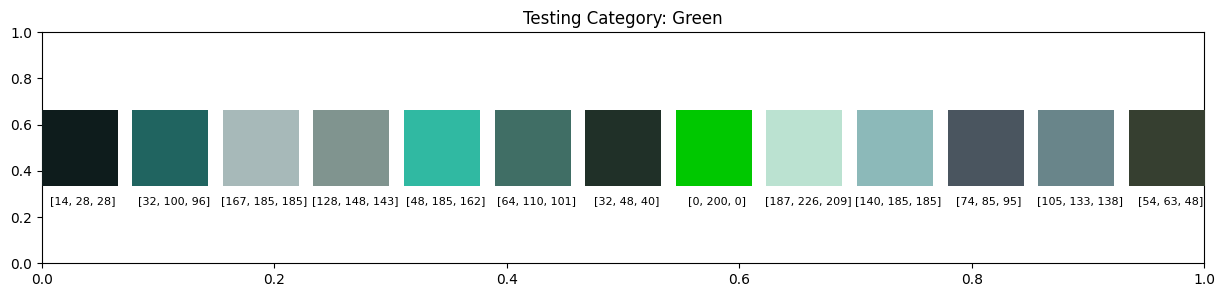

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Use your actual dictionary here
check_colours = {
    "Green": [[14, 28, 28], [32, 100, 96], [167, 185, 185], [128, 148, 143], [48, 185, 162], [64, 110, 101], [32, 48, 40], [0, 200, 0], [187, 226, 209], [140, 185, 185], [74, 85, 95], [105, 133, 138], [54, 63, 48]],
}

def plot_colors(color_dict):
    for name, list_of_rgbs in color_dict.items():
        plt.figure(figsize=(15, 3))
        plt.title(f"Testing Category: {name}")
        for i, rgb in enumerate(list_of_rgbs):
            # Create a 10x10 square of the color
            block = np.full((10, 10, 3), rgb, dtype=np.uint8)
            plt.subplot(1, len(list_of_rgbs), i + 1)
            plt.imshow(block)
            plt.axis('off')
            plt.text(5, 12, f"{rgb}", fontsize=8, ha='center')
        plt.show()

plot_colors(check_colours)

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

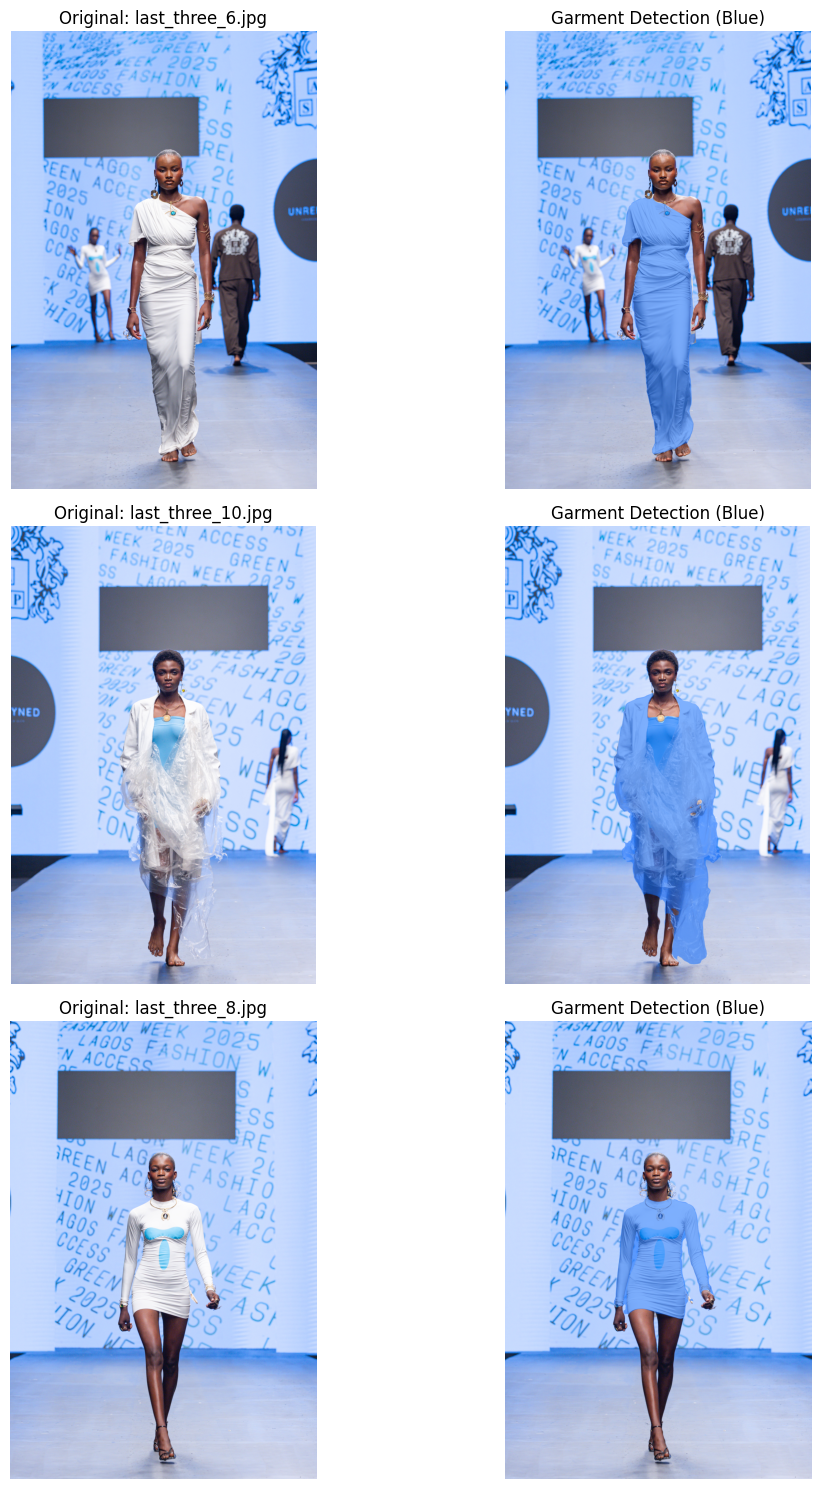

In [4]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from fashn_human_parser import FashnHumanParser

def audit_segmentation(main_folder, num_samples=3):
    parser = FashnHumanParser() # Auto-detects GPU/CPU
    
    # 1. Gather all images from your brand folders
    all_images = []
    for root, dirs, files in os.walk(main_folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_images.append(os.path.join(root, f))
    
    if not all_images:
        print("No images found! Check your folder path.")
        return

    # 2. Pick random samples
    samples = random.sample(all_images, min(num_samples, len(all_images)))
    
    # 3. Process and Plot
    fig, axes = plt.subplots(len(samples), 2, figsize=(12, 5 * len(samples)))
    
    for i, img_path in enumerate(samples):
        # Predict mask
        mask = parser.predict(img_path)
        
        # Load and prepare image
        img = np.array(Image.open(img_path).convert("RGB"))
        
        # Create a mask specifically for clothing (IDs 3-7, 10)
        # 3:Top, 4:Dress, 5:Skirt, 6:Pants, 7:Belt, 10:Scarf
        clothing_ids = [3, 4, 5, 6, 7, 10]
        garment_mask = np.isin(mask, clothing_ids)
        
        # Create overlay (Original image + Blue tint on clothes)
        overlay = img.copy()
        overlay[garment_mask] = [0, 100, 255] # Electric Blue
        blended = cv2.addWeighted(overlay, 0.5, img, 0.5, 0)
        
        # Plotting
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original: {os.path.basename(img_path)}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(blended)
        axes[i, 1].set_title("Garment Detection (Blue)")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# RUN THIS: Change path to your Lagos FW folder
audit_segmentation(r"C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\data\runway\adage_studio_project_x_unrefyned")